Setup


In [1]:
# Core
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
# !pip install xgboost lightgbm
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Explainability & Stats
import shap
from sklearn.inspection import permutation_importance
import statsmodels.api as sm

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Part I: Synthetic Data Generation & Model Estimation
Part 1 uses a synthetic dataset of American call option prices generated with a binomial model. The task is to train machine learning models to replicate that option pricing function, try to push the prediction as close to real price as possible, and interpret the best-performing model through explainability and diagnostic analysis.

### 1. Load Synthetic dataset

In [ ]:
df = pd.read_csv("data/american_call_option.csv")

### 2. Quick sanity checks

In [3]:
print(f'Dataset shape (rows, columns): {df.shape}\n')
print(df.dtypes)
print(f'\nShow some first rows \n {df.head()}')

Dataset shape (rows, columns): (31173, 8)

S           float64
X             int64
T           float64
r           float64
div         float64
v           float64
n             int64
Amercall    float64
dtype: object

Show some first rows 
             S    X         T         r       div         v      n   Amercall
0   91.850064  100  0.754349  0.073504  0.039149  0.466568  15000  12.199666
1  125.318545  100  0.233275  0.032105  0.097830  0.511820  15000  26.909800
2   80.577346  100  4.249918  0.053841  0.073773  0.505688  15000  20.475375
3   84.656262  100  0.361553  0.053248  0.086968  0.310740  15000   1.530428
4   72.888120  100  0.479781  0.037619  0.009449  0.436926  15000   2.111835


In [4]:
df.nunique()

S           31171
X               1
T           31173
r           24889
div         31172
v           31171
n               1
Amercall    31151
dtype: int64

Strike Price (X) is fixed at 100 and Number of steps (n) is 15000. We don't need them for the purpose of this ML model.

Outlier Summary (IQR Method):
  Variable       Q1        Q3      IQR  Lower Bound  Upper Bound  \
1        T   0.3993    0.9955   0.5962      -0.4951       1.8899   
0        S  85.0070  115.1716  30.1646      39.7601     160.4186   
2        r   0.0062    0.0683   0.0620      -0.0868       0.1613   
3      div   0.0247    0.0748   0.0501      -0.0504       0.1499   
4        v   0.2227    0.4746   0.2519      -0.1551       0.8525   

   Outlier Count  Outlier %     Min       Max      Mean    Median  Std Dev  
1           5980    19.1833   0.100    4.9992    1.1521    0.6957   1.2190  
0              0     0.0000  70.004  129.9985  100.0766  100.1841  17.3511  
2              0     0.0000   0.000    0.1000    0.0398    0.0372   0.0325  
3              0     0.0000   0.000    0.1000    0.0497    0.0494   0.0289  
4              0     0.0000   0.100    0.6000    0.3497    0.3505   0.1447  


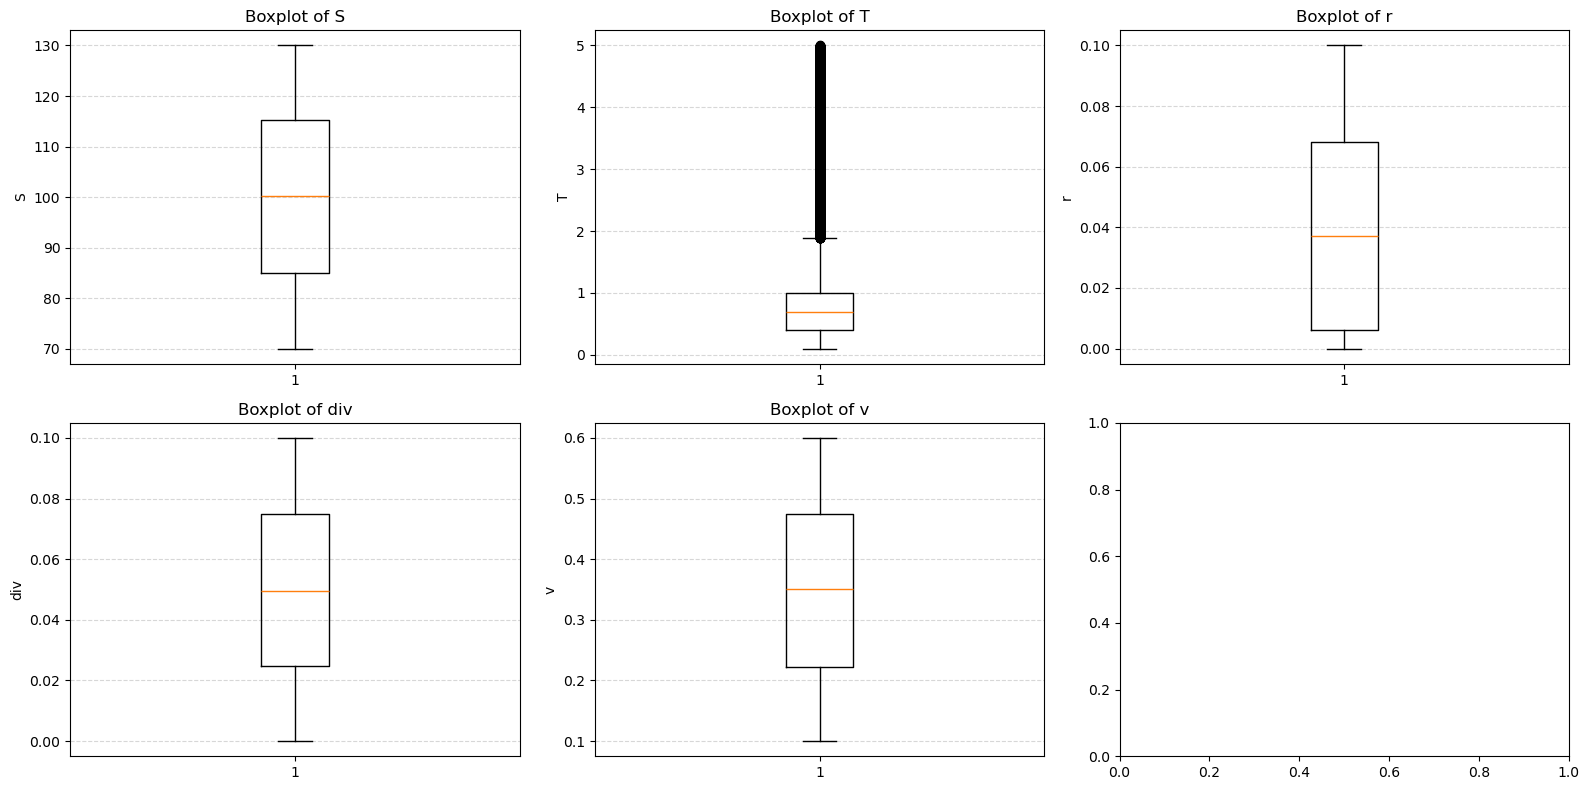

In [5]:
# BOX PLOT VIZUALIZATIONS

features = df.drop(columns=["Amercall", "n","X"])
# Function to summarize outliers using IQR
def outlier_summary_iqr(data: pd.DataFrame) -> pd.DataFrame:
    """
    Detect outliers in each numeric column using the IQR rule:
    Outlier if value < Q1 - 1.5*IQR or value > Q3 + 1.5*IQR
    """
    summary = []

    for col in data.columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]
        outlier_count = outliers.shape[0]
        outlier_pct = (outlier_count / len(data)) * 100

        summary.append({
            'Variable': col,
            'Q1': q1,
            'Q3': q3,
            'IQR': iqr,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound,
            'Outlier Count': outlier_count,
            'Outlier %': outlier_pct,
            'Min': data[col].min(),
            'Max': data[col].max(),
            'Mean': data[col].mean(),
            'Median': data[col].median(),
            'Std Dev': data[col].std()
        })

    return pd.DataFrame(summary).sort_values(by='Outlier Count', ascending=False)

# Generate outlier summary table
outlier_summary = outlier_summary_iqr(features)

print("Outlier Summary (IQR Method):")
print(outlier_summary.round(4))

# Boxplots for visual inspection
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features.columns):
    axes[i].boxplot(features[col].dropna(), vert=True)
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Outliers only appear in time to maturity, but these observations reflect the natural range of option contracts and were therefore retained.

### 3. Feature Engineering

To improve model performance while keeping the feature set consistent across all models, several finance-informed features were engineered from the original variables. These transformations are designed to capture key drivers of American call option values, including time scaling, cost of carry, dividend effects, and the extent to which the option is in the money.

In [6]:
# Time scaling term
df["sqrtT"] = np.sqrt(np.maximum(df["T"], 0.0))

# Cost of carry over the life of the option
df["rT"] = df["r"] * df["T"]
df["divT"] = df["div"] * df["T"]

# Volatility scaled by time
df["v_sqrtT"] = df["v"] * df["sqrtT"]

# Intrinsic value of an American call option
df["intrinsic"] = np.maximum(df["S"] - df["X"], 0.0)

# Indicator for whether the option is in the money
df["itm_flag"] = (df["S"] > df["X"]).astype(int)

# Final feature set used for all models
features = [
    "S",
    "T",
    "r",
    "div",
    "v",
    "sqrtT",
    "rT",
    "divT",
    "v_sqrtT",
    "intrinsic",
    "itm_flag"
]

X = df[features]
y = df["Amercall"]

### 4. Train/Test Split

The train-test split and cross-validation folds were stratified using quantile-based bins of the target variable (Amercall). This helps preserve the distribution of option prices across data partitions. 

In addition, the distribution of time to maturity (T) was inspected separately as a robustness check, given its economic importance and wide variation in the dataset.

In [7]:
# Create y bins
n_bins = 10
y_bins = pd.qcut(y, q=n_bins, labels=False, duplicates="drop")

# Train-test split with stratification on y bins
X_train, X_test, y_train, y_test, y_bins_train, y_bins_test = train_test_split(
    X,
    y,
    y_bins,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_bins,
    shuffle=True
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (24938, 11)
Test shape : (6235, 11)



Summary statistics for T in train and test:
             Train_T       Test_T
count   24938.000000  6235.000000
min         0.100017     0.100103
q05         0.160393     0.158141
q25         0.399876     0.395842
median      0.696528     0.692629
mean        1.148044     1.168335
q75         0.995213     0.996710
q95         4.151595     4.255176
max         4.998937     4.999161
std         1.211900     1.247176


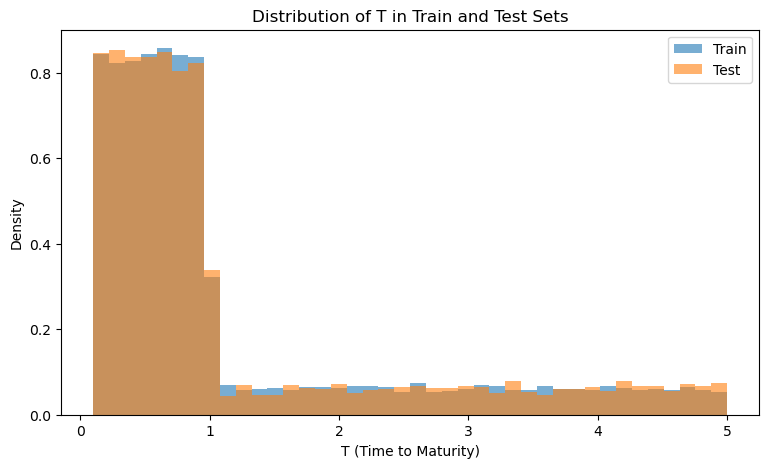

In [8]:
# Check T distribution after train-test split
def summarize_series(s, name):
    return pd.Series({
        "count": len(s),
        "min": s.min(),
        "q05": s.quantile(0.05),
        "q25": s.quantile(0.25),
        "median": s.median(),
        "mean": s.mean(),
        "q75": s.quantile(0.75),
        "q95": s.quantile(0.95),
        "max": s.max(),
        "std": s.std()
    }, name=name)

T_summary = pd.concat([
    summarize_series(X_train["T"], "Train_T"),
    summarize_series(X_test["T"], "Test_T")
], axis=1)

print("\nSummary statistics for T in train and test:")
print(T_summary.round(6))

plt.figure(figsize=(9, 5))
plt.hist(X_train["T"], bins=40, alpha=0.6, density=True, label="Train")
plt.hist(X_test["T"], bins=40, alpha=0.6, density=True, label="Test")
plt.xlabel("T (Time to Maturity)")
plt.ylabel("Density")
plt.title("Distribution of T in Train and Test Sets")
plt.legend()
plt.show()


Inspecting T, the train and test sets have very similar quartiles, medians, and overall ranges, while the overlaid histograms show strong overlap across the full support. Although the test set has a slightly higher mean and upper-tail quantiles, the differences are small.

In [9]:
# Stratified CV based on y bins from the training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(cv.split(X_train, y_bins_train))

In [23]:
# Evaluation helper
# =========================================================
# A small evaluation helper is used to calculate the main regression metrics consistently across all models. 
# Predicted option prices are clipped at zero for reporting in case model predict negative prediction values.

def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # Option prices cannot be negative
    y_pred = np.maximum(y_pred, 0.0)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

### 5. Traditional Models

#### Model specifications
This section implements a range of non-neural regression models, including Linear Regression, Support Vector Regression (SVR), and tree-based methods such as Decision Trees, Random Forest, XGBoost, and LightGBM.

- Scaling is included inside the pipeline for scale-sensitive models to prevent leakage in CV.
- Tree-based models do not require scaling.

In [11]:
models = {
    "Linear Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        "param_distributions": None
    },

    "SVR": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR(kernel="rbf"))
        ]),
        "param_distributions": {
            "model__C": [1, 10],
            "model__epsilon": [0.01, 0.05],
            "model__gamma": ["scale"]
            }
    },

    "Decision Tree": {
        "pipeline": Pipeline([
            ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
        ]),
        "param_distributions": {
            "model__max_depth": [3, 5, 8, 12, None],
            "model__min_samples_split": [2, 5, 10, 20],
            "model__min_samples_leaf": [1, 2, 5, 10]
        }
    },

    "Random Forest": {
        "pipeline": Pipeline([
            ("model", RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        "param_distributions": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 8, 12, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 5]
        }
    },

    "XGBoost": {
        "pipeline": Pipeline([
            ("model", XGBRegressor(
                random_state=RANDOM_STATE,
                objective="reg:squarederror",
                n_jobs=-1,
                verbosity=0
            ))
        ]),
        "param_distributions": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },

    "LightGBM": {
        "pipeline": Pipeline([
            ("model", LGBMRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1
            ))
        ]),
        "param_distributions": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__num_leaves": [31, 63, 127],
            "model__max_depth": [-1, 5, 10],
            "model__subsample": [0.8, 1.0]
        }
    }
}

#### Train and tune models

Randomized search was used to balance predictive performance and computational feasibility

In [ ]:
results = []
best_models = {}

for model_name, spec in models.items():
    print(f"\n{'='*70}")
    print(f"Running: {model_name}")

    pipe = spec["pipeline"]
    param_distributions = spec["param_distributions"]

    # Linear Regression is used as a baseline model and is not tuned here.
    if param_distributions is None:
        cv_scores = cross_val_score(
            pipe,
            X_train,
            y_train,
            cv=cv_splits,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1
        )

        pipe.fit(X_train, y_train)
        best_model = pipe
        best_params = {}

        cv_rmse_mean = -cv_scores.mean()
        cv_rmse_std = cv_scores.std()

    # For the remaining models, randomized search is used for hyperparameter tuning.
    else:
        # SVR is tuned more lightly because RBF-based SVR is computationally expensive
        # on large datasets, so a smaller search is used to keep runtime manageable.
        if model_name == "SVR":
            n_iter_search = 4
        else:
            n_iter_search = 12

        random_search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_distributions,
            n_iter=n_iter_search,
            scoring="neg_root_mean_squared_error",
            cv=cv_splits,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=1
        )

        random_search.fit(X_train, y_train)

        best_model = random_search.best_estimator_
        best_params = random_search.best_params_
        cv_rmse_mean = -random_search.best_score_
        cv_rmse_std = np.nan

    # Final evaluation is carried out on the untouched TEST SET
    y_test_pred = best_model.predict(X_test)
    metrics = evaluate_regression(y_test, y_test_pred)

    results.append({
        "Model": model_name,
        "CV_RMSE_Mean": cv_rmse_mean,
        "CV_RMSE_Std": cv_rmse_std,
        "Test_MSE": metrics["MSE"],
        "Test_RMSE": metrics["RMSE"],
        "Test_MAE": metrics["MAE"],
        "Test_R2": metrics["R2"],
        "Best_Params": best_params
    })

    best_models[model_name] = best_model

    print("Best parameters:", best_params)
    print("Test MSE :", round(metrics["MSE"], 6))
    print("Test RMSE:", round(metrics["RMSE"], 6))
    print("Test MAE :", round(metrics["MAE"], 6))
    print("Test R²  :", round(metrics["R2"], 6))


Running: Linear Regression


Best parameters: {}
Test MSE : 1.998825
Test RMSE: 1.413798
Test MAE : 1.010036
Test R²  : 0.986366

Running: SVR
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters: {'model__gamma': 'scale', 'model__epsilon': 0.01, 'model__C': 10}
Test MSE : 0.016116
Test RMSE: 0.126949
Test MAE : 0.050044
Test R²  : 0.99989

Running: Decision Tree
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': None}
Test MSE : 2.377586
Test RMSE: 1.541942
Test MAE : 0.886727
Test R²  : 0.983782

Running: Random Forest
Fitting 5 folds for each of 12 candidates, totalling 60 fits


#### Comparison Table


Final model comparison:
               Model  CV_RMSE_Mean  Test_RMSE  Test_MAE   Test_R2
0                SVR      0.143471   0.126949  0.050044  0.999890
1           LightGBM      0.484924   0.468300  0.270575  0.998504
2            XGBoost      0.508952   0.487829  0.327944  0.998377
3      Random Forest      0.904507   0.864705  0.433943  0.994900
4  Linear Regression      1.568463   1.413798  1.010036  0.986366
5      Decision Tree      1.652777   1.541942  0.886727  0.983782


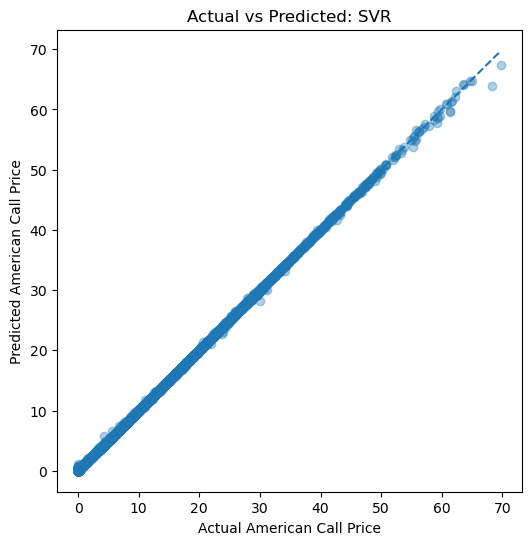

In [ ]:
results_df = pd.DataFrame(results).sort_values("Test_RMSE").reset_index(drop=True)

print("\nFinal model comparison:")
print(results_df[["Model", "CV_RMSE_Mean", "Test_RMSE", "Test_MAE", "Test_R2"]].round(6))


# =========================================================
# 11. Plot actual vs predicted for the best model
# =========================================================
best_model_name = results_df.loc[0, "Model"]
best_model = best_models[best_model_name]

y_pred_best = best_model.predict(X_test)
y_pred_best = np.maximum(y_pred_best, 0.0)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.35)
plt.xlabel("Actual American Call Price")
plt.ylabel("Predicted American Call Price")
plt.title(f"Actual vs Predicted: {best_model_name}")

min_val = min(np.min(y_test), np.min(y_pred_best))
max_val = max(np.max(y_test), np.max(y_pred_best))
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

### 6. Neural Network
A feedforward neural network was implemented in Keras in this section. This architecture was chosen because the dataset is tabular rather than sequential, making dense layers a more appropriate starting point than recurrent or convolutional networks. 

- ReLU activations were used in the hidden layers. I preferred it over sigmoid here because it tends to train more efficiently and avoids severe vanishing-gradient issues.
- Adam was adopted as the optimizer due to its strong empirical performance for Keras-based pricing models. 
- Early stopping was set up to reduce overfitting and improve generalization.
- The model was trained on the training subset with MSE loss, while a validation subset was used to track performance during training and determine when to stop.

In [ ]:
# Reproducibility
tf.keras.utils.set_random_seed(RANDOM_STATE)

# Create a validation split from the training set
# I stratify using binned y so that the validation set remains reasonably balanced across option-price levels.
n_bins_nn = 10
y_bins_nn = pd.qcut(y_train, q=n_bins_nn, labels=False, duplicates="drop")

X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_bins_nn,
    shuffle=True
)

print("NN train shape:", X_train_nn.shape, y_train_nn.shape)
print("NN val shape  :", X_val_nn.shape, y_val_nn.shape)

# Scale features for the neural network
scaler_nn = StandardScaler()
X_train_nn_scaled = scaler_nn.fit_transform(X_train_nn)
X_val_nn_scaled = scaler_nn.transform(X_val_nn)
X_test_scaled = scaler_nn.transform(X_test)

# Convert targets to numpy arrays
y_train_nn = np.asarray(y_train_nn, dtype=float)
y_val_nn = np.asarray(y_val_nn, dtype=float)
y_test_nn = np.asarray(y_test, dtype=float)

NN train shape: (19950, 11) (19950,)
NN val shape  : (4988, 11) (4988,)


#### Build NN model

In [ ]:
# Two hidden layers are used
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_nn_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="linear")
])

# ---------------------------------------------------------

# Compile the model
nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ]
)

# ---------------------------------------------------------

# Early stopping
# Patience=20 is a good balance here: it allows the model enough time to improve, but stops training before wasting many epochs once validation loss plateaus.
# restore_best_weights=True to save the best performing model
early_stopping_cb = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

#### Train & Evaluate NN Model

In [ ]:
# Early stopping will usually end training earlier if validation performance stops improving
history = nn_model.fit(
    X_train_nn_scaled,
    y_train_nn,
    validation_data=(X_val_nn_scaled, y_val_nn),
    epochs=300,
    batch_size=64,
    verbose=0,
    callbacks=[early_stopping_cb]
)

# ---------------------------------------------------------

# Predict on the untouched test set
y_test_pred_nn = nn_model.predict(X_test_scaled, verbose=0).ravel()

# Use the same helper as the traditional models
nn_metrics = evaluate_regression(y_test_nn, y_test_pred_nn)

print("\nKeras Neural Network Test Performance")
print("Test MSE :", round(nn_metrics["MSE"], 6))
print("Test RMSE:", round(nn_metrics["RMSE"], 6))
print("Test MAE :", round(nn_metrics["MAE"], 6))
print("Test R²  :", round(nn_metrics["R2"], 6))


Keras Neural Network Test Performance
Test MSE : 0.005648
Test RMSE: 0.07515
Test MAE : 0.049992
Test R²  : 0.999961


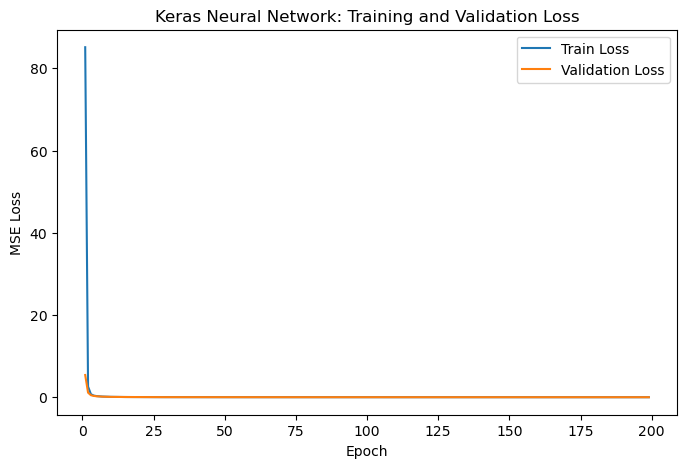

In [ ]:
# Add the neural network to the common comparison table
results.append({
    "Model": "Keras Neural Network",
    "CV_RMSE_Mean": np.nan,   # not CV-based; validation set used instead
    "CV_RMSE_Std": np.nan,
    "Test_MSE": nn_metrics["MSE"],
    "Test_RMSE": nn_metrics["RMSE"],
    "Test_MAE": nn_metrics["MAE"],
    "Test_R2": nn_metrics["R2"],
    "Best_Params": {
        "hidden_layers": [64, 32],
        "activation": "relu",
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "loss": "mse",
        "batch_size": 64,
        "epochs_max": 300,
        "early_stopping_patience": 20
    }
})

best_models["Keras Neural Network"] = nn_model

# Vizualization: learning curves
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df.index + 1, history_df["loss"], label="Train Loss")
plt.plot(history_df.index + 1, history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Keras Neural Network: Training and Validation Loss")
plt.legend()
plt.show()

The training loss is initially high because the network starts from random weights, but it declines very quickly in the first few epochs as the model begins to learn the pricing relationship. 

The validation loss follows a similar pattern and remains close to the training loss, suggesting stable learning without clear signs of severe overfitting.

### 7. Final Comparison

In [ ]:
results_df = pd.DataFrame(results).sort_values("Test_RMSE").reset_index(drop=True)
print("\nFinal model comparison:")
print(
    results_df[
        ["Model", "Test_MSE", "Test_RMSE", "Test_MAE", "Test_R2"]
    ].round(6)
)

# Update best model
best_model_name = results_df.loc[0, "Model"]
best_model = best_models[best_model_name]
print("Best overall model:", best_model_name)

# Generate predictions using the correct input format
if best_model_name == "Keras Neural Network":
    y_pred_best = best_model.predict(X_test_scaled, verbose=0).ravel()
else:
    y_pred_best = best_model.predict(X_test)

y_pred_best = np.maximum(y_pred_best, 0.0)


Final model comparison:
                  Model  Test_MSE  Test_RMSE  Test_MAE   Test_R2
0  Keras Neural Network  0.005648   0.075150  0.049992  0.999961
1                   SVR  0.016116   0.126949  0.050044  0.999890
2              LightGBM  0.219305   0.468300  0.270575  0.998504
3               XGBoost  0.237977   0.487829  0.327944  0.998377
4         Random Forest  0.747715   0.864705  0.433943  0.994900
5     Linear Regression  1.998825   1.413798  1.010036  0.986366
6         Decision Tree  2.377586   1.541942  0.886727  0.983782
Best overall model: Keras Neural Network


The neural network achieved the best overall predictive performance, followed closely by SVR. This suggests that the binomial pricing function in the synthetic dataset is highly nonlinear but smooth enough to be learned effectively without overfitting. 

Keras NN is the top model on every main error metric, with the lowest MSE, RMSE, and MAE, and the highest R2. Interestingly, the fact that its RMSE is much lower than SVR’s while the MAE is almost the same. It suggests the NN is not just slightly better on average, but is probably making fewer large mistakes. In other words, both models handle most observations well, but the neural network seems better in the harder regions of the pricing surface.

Linear Regression performs surprisingly well. That is actually a nice result. It suggests that the engineered features are doing useful work.

Decision Tree is the weakest model, which is exactly what we would expect. It works better when data is categorical, has clear "if-then" rules. In the world of Option Pricing (when the target is a smooth, continuous mathematical function), it is considered relatively poor. The fact that Random Forest is much better than Decision Tree is a clean illustration of the benefit of ensemble learning.

One more important point: all the R2 values are very high, even for weaker models. For a synthetic dataset, that is not surprising.

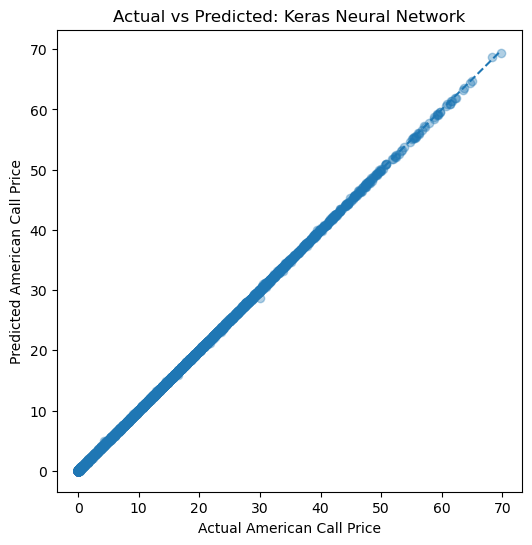

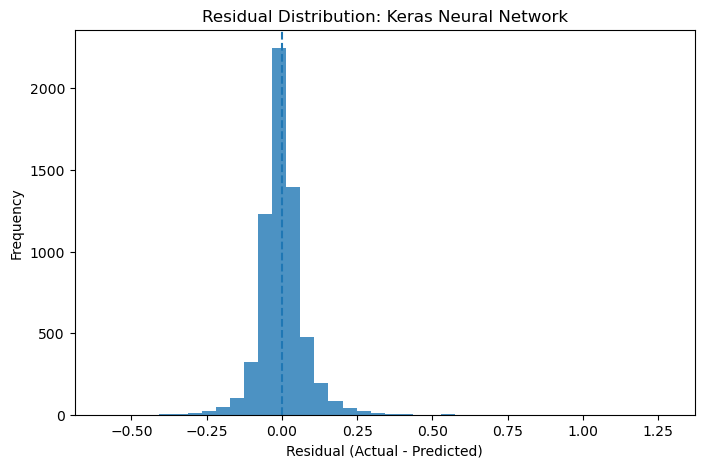

In [ ]:
# Vizualizations on Best Model

# Plot: Actual vs Predicted plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.35)
plt.xlabel("Actual American Call Price")
plt.ylabel("Predicted American Call Price")
plt.title(f"Actual vs Predicted: {best_model_name}")

min_val = min(np.min(y_test), np.min(y_pred_best))
max_val = max(np.max(y_test), np.max(y_pred_best))
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

# Plot: Histogram of residuals
residuals = np.asarray(y_test, dtype=float) - np.asarray(y_pred_best, dtype=float)

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=40, alpha=0.8)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title(f"Residual Distribution: {best_model_name}")
plt.show()

- The residuals are strongly concentrated around zero, which means the neural network is getting most predictions very close to the true option price.

- The distribution looks roughly bell-shaped, so there is no obvious severe instability.

### 8. Model Interpretability and Diagnostic Analysis
#### SHAP-Based Interpretation of NN 
SHAP was used to interpret the neural network because it provides both global and local explanations of model behavior.

  0%|          | 0/200 [00:00<?, ?it/s]

C:\Users\Admin\AppData\Local\Temp\ipykernel_31112\1662787990.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


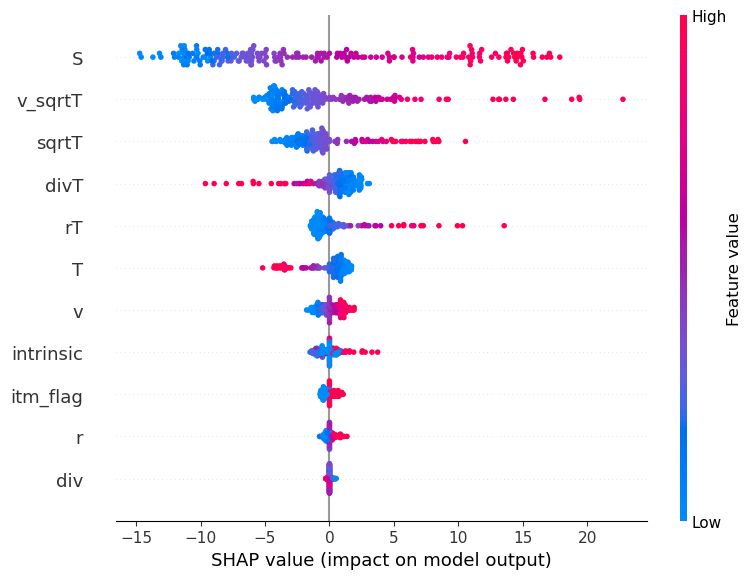

In [ ]:
# Use the scaled training data because the neural network was trained on scaled inputs
feature_names = X_train.columns.tolist()

# Small background set for SHAP
background_idx = np.random.choice(X_train_nn_scaled.shape[0], size=100, replace=False)
background = X_train_nn_scaled[background_idx]

# Small explanation sample from test set
explain_idx = np.random.choice(X_test_scaled.shape[0], size=200, replace=False)
X_explain = X_test_scaled[explain_idx]

# Prediction wrapper returning 1D output
def nn_predict(x):
    return nn_model.predict(x, verbose=0).ravel()

explainer = shap.KernelExplainer(nn_predict, background)
shap_values = explainer.shap_values(X_explain, nsamples=100)

# Summary plot
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    show=True
)

- S is the most important feature. Higher S pushes predictions upward, while lower S pushes them downward. That is exactly what we expect for a call option.
- v_sqrtT and sqrtT are the next strongest drivers. This is also sensible, because option value is strongly linked to the interaction between volatility and time to maturity. Uncertainty over time increases option value.
- rT has a mostly positive effect, which is reasonable for call pricing.
- divT has a mostly negative effect, which also makes sense: higher dividends tend to reduce call values because they lower the expected future stock price.
- T and v alone are less important than their transformed versions (sqrtT, v_sqrtT). That suggests our feature engineering worked well.
- intrinsic and itm_flag matter, but less than S. That is not surprising, because with strike fixed at 100, these variables overlap a lot with the information already contained in S.

#### Performance across Moneyness Buckets
To assess where the neural network performs well or poorly, an additional diagnostic analysis was conducted across moneyness buckets (Since the strike price is fixed across all observations, moneyness reduces to a scaled transformation of the spot price. Nevertheless, grouping contracts into OTM, ATM, and ITM regions remains economically meaningful)

In [ ]:
# Use original unscaled test features for bucket assignment
diagnostic_df = X_test.copy()
diagnostic_df["y_true"] = np.asarray(y_test, dtype=float)
diagnostic_df["y_pred"] = y_pred_best  
diagnostic_df["abs_error"] = np.abs(diagnostic_df["y_true"] - diagnostic_df["y_pred"])
diagnostic_df["sq_error"] = (diagnostic_df["y_true"] - diagnostic_df["y_pred"]) ** 2

# Moneyness
diagnostic_df["moneyness"] = diagnostic_df["S"] / 100.0   # since strike X is constant at 100

# Define buckets
diagnostic_df["moneyness_bucket"] = pd.cut(
    diagnostic_df["moneyness"],
    bins=[-np.inf, 0.98, 1.02, np.inf],
    labels=["OTM", "ATM", "ITM"]
)

bucket_results = diagnostic_df.groupby("moneyness_bucket").apply(
    lambda d: pd.Series({
        "Count": len(d),
        "MSE": np.mean((d["y_true"] - d["y_pred"]) ** 2),
        "RMSE": np.sqrt(np.mean((d["y_true"] - d["y_pred"]) ** 2)),
        "MAE": np.mean(np.abs(d["y_true"] - d["y_pred"])),
        "Mean_True_Price": np.mean(d["y_true"]),
        "Mean_Pred_Price": np.mean(d["y_pred"]),
        "RMSE by the mean true price": (
            np.sqrt(np.mean((d["y_true"] - d["y_pred"]) ** 2)) / np.mean(d["y_true"])
        ) * 100
    })
).reset_index()

print(bucket_results)

  moneyness_bucket   Count       MSE      RMSE       MAE  Mean_True_Price  \
0              OTM  2884.0  0.003991  0.063178  0.041021         6.233263   
1              ATM   424.0  0.007113  0.084338  0.058016        12.560621   
2              ITM  2927.0  0.007067  0.084066  0.057668        23.690883   

   Mean_Pred_Price  RMSE by the mean true price  
0         6.236006                     1.013557  
1        12.570816                     0.671446  
2        23.687124                     0.354847  


C:\Users\Admin\AppData\Local\Temp\ipykernel_31112\2666906935.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_results = diagnostic_df.groupby("moneyness_bucket").apply(
C:\Users\Admin\AppData\Local\Temp\ipykernel_31112\2666906935.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bucket_results = diagnostic_df.groupby("moneyness_bucket").apply(


The neural network performed well across all moneyness buckets. 

In absolute terms, OTM options exhibit the lowest pricing errors across all metrics. However, since average option prices increase substantially from OTM to ITM, relative errors tell a more informative story: RMSE as a percentage of the mean option price was highest for OTM contracts and lowest for ITM contracts. This suggests that the model remains highly accurate across regimes, with proportionally better performance on higher-premium ITM options and relatively greater difficulty in the lower-premium OTM region. 

Anyway, the close alignment between mean predicted and mean actual prices in all buckets also indicates little evidence of systematic bias.

# Part 2: Real-World Option Chain Analysis
This section involves the real world options data that is created based on the NFLX option-chain data. Only the call options have been analyzed.

Cleaning will be done followed by solving 2 seperated tasks: implied volatility prediction and bid-ask spread prediction.

### Data Scrape

In [2]:
# import yfinance as yf
# import pandas as pd
# from datetime import datetime

# # Setup Ticker
# ticker_symbol = 'NFLX'  
# ticker = yf.Ticker(ticker_symbol)

# # Capture Global Snapshot Variables
# stock_price = ticker.history(period="1d")['Close'].iloc[-1]
# # Some tickers return None for dividendYield; we default to 0
# dividend_yield = ticker.info.get('dividendYield', 0)
# if dividend_yield is None: dividend_yield = 0

# # Iterate through all Expiration Dates
# options_dates = ticker.options
# all_options_list = []

# for date in options_dates:
#     # Fetch option chain for each maturity 
#     opt_chain = ticker.option_chain(date)
    
#     # Process Calls
#     calls = opt_chain.calls.copy()
#     calls['Expiry'] = date
#     calls['Type'] = 'Call'
    
#     # Process Puts
#     puts = opt_chain.puts.copy()
#     puts['Expiry'] = date
#     puts['Type'] = 'Put'
    
#     # Combine the chains for this date
#     all_options_list.append(pd.concat([calls, puts]))

# # Final Data Assembly
# df_raw = pd.concat(all_options_list, ignore_index=True)

# # Add columns for ML Feature Engineering later
# fetch_date = datetime.now()
# df_raw['Date_Fetched'] = fetch_date.strftime('%Y-%m-%d')
# df_raw['Expiry'] = pd.to_datetime(df_raw['Expiry'])

# # Calculate Days to Expiration
# df_raw['Days to Expiration'] = (df_raw['Expiry'] - pd.to_datetime(df_raw['Date_Fetched'])).dt.days

# # Add constant snapshot values to every row
# df_raw['Stock Price'] = stock_price
# # df_raw['Dividend Yield'] = dividend_yield 
# df_raw['Treasury Rate'] = 0.055  # Risk-free rate (not important)

# # Export Raw Dataset
# csv_name = f'{ticker_symbol}_raw_data.csv'
# df_raw.to_csv(csv_name, index=False)

# print(f"Dataset for {ticker_symbol} saved.")

In [ ]:
# Load data
df_s2 = pd.read_csv("data/NFLX_options_extended.csv")
df_s2

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,...,inTheMoney,contractSize,currency,Expiry,Type,Date,Days to Expiration,Stock Price,Dividend Yield,Treasury Rate
0,NFLX260417C00000500,2026-04-13 16:47:59+00:00,0.5,102.60,101.05,104.30,8.099998,8.571427,1.0,94.0,...,True,REGULAR,USD,4/17/2026,Call,4/13/2026,4,103.275002,0.4,0.055
1,NFLX260417C00001000,2026-04-13 17:21:45+00:00,1.0,102.13,100.55,103.85,4.229996,4.320731,47.0,22.0,...,True,REGULAR,USD,4/17/2026,Call,4/13/2026,4,103.275002,0.4,0.055
2,NFLX260417C00001500,2026-04-13 17:21:45+00:00,1.5,101.68,100.05,103.40,3.949997,4.041744,9.0,10.0,...,True,REGULAR,USD,4/17/2026,Call,4/13/2026,4,103.275002,0.4,0.055
3,NFLX260417C00002000,2026-04-13 17:22:22+00:00,2.0,101.21,99.55,102.95,10.260002,11.280927,6.0,8.0,...,True,REGULAR,USD,4/17/2026,Call,4/13/2026,4,103.275002,0.4,0.055
4,NFLX260417C00002500,2026-04-13 17:22:22+00:00,2.5,100.76,99.05,102.55,4.010002,4.144705,3.0,3.0,...,True,REGULAR,USD,4/17/2026,Call,4/13/2026,4,103.275002,0.4,0.055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6286,NFLX281215P00155000,2026-04-09 18:07:39+00:00,155.0,55.35,52.75,57.00,0.000000,0.000000,10.0,18.0,...,True,REGULAR,USD,12/15/2028,Put,4/13/2026,977,103.275002,0.4,0.055
6287,NFLX281215P00160000,2026-03-04 15:14:37+00:00,160.0,63.11,0.00,0.00,0.000000,0.000000,NaN,0.0,...,True,REGULAR,USD,12/15/2028,Put,4/13/2026,977,103.275002,0.4,0.055
6288,NFLX281215P00165000,2026-03-04 15:13:20+00:00,165.0,67.55,0.00,0.00,0.000000,0.000000,NaN,0.0,...,True,REGULAR,USD,12/15/2028,Put,4/13/2026,977,103.275002,0.4,0.055
6289,NFLX281215P00170000,2026-01-21 14:33:29+00:00,170.0,87.00,70.50,75.00,0.000000,0.000000,NaN,0.0,...,True,REGULAR,USD,12/15/2028,Put,4/13/2026,977,103.275002,0.4,0.055


In [4]:
# Drop rows with critical missing values
df_call = df_s2[
    (df_s2['Type'] == 'Call') &
    df_s2[["bid", "ask", "impliedVolatility",
    "Days to Expiration", "Stock Price", "strike", "volume", "openInterest"]].notnull().all(axis=1)
].copy()
df_call.shape

(3252, 21)

In [5]:
df_call.dtypes

contractSymbol         object
lastTradeDate          object
strike                float64
lastPrice             float64
bid                   float64
ask                   float64
change                float64
percentChange         float64
volume                float64
openInterest          float64
impliedVolatility     float64
inTheMoney               bool
contractSize           object
currency               object
Expiry                 object
Type                   object
Date                   object
Days to Expiration      int64
Stock Price           float64
Dividend Yield        float64
Treasury Rate         float64
dtype: object

#### Basic Feature Engineering

In [6]:
# Bid-ask spread (relative)
df_call["spread"] = (df_call["ask"] - df_call["bid"]) / ((df_call["ask"] + df_call["bid"]) / 2)

# Moneyness
df_call["moneyness"] = df_call["Stock Price"] / df_call["strike"]

# Dummy variable
df_call["inTheMoney_dummy"] = df_call["inTheMoney"].astype(int)

# Log transform for liquidity indicators (to reduce skew)
df_call["log_volume"] = np.log1p(df_call["volume"])
df_call["log_openInterest"] = np.log1p(df_call["openInterest"])

# Time scaling
df_call["sqrtT"] = np.sqrt(df_call["Days to Expiration"])   # In option pricing, uncertainty grows with √time, not linearly with time

# Log Moneyness
df_call["log_moneyness"] = np.log(df_call["moneyness"])

#### EDA

In [7]:
def outlier_summary_iqr(data: pd.DataFrame) -> pd.DataFrame:
    """
    Detect outliers in each numeric column using the IQR rule:
    Outlier if value < Q1 - 1.5*IQR or value > Q3 + 1.5*IQR
    """
    summary = []

    for col in data.columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]
        outlier_count = outliers.shape[0]
        outlier_pct = (outlier_count / len(data)) * 100

        summary.append({
            'Variable': col,
            'Q1': q1,
            'Q3': q3,
            'IQR': iqr,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound,
            'Outlier Count': outlier_count,
            'Outlier %': outlier_pct,
            'Min': data[col].min(),
            'Max': data[col].max(),
            'Mean': data[col].mean(),
            'Median': data[col].median(),
            'Std Dev': data[col].std()
        })

    return pd.DataFrame(summary).sort_values(by='Outlier Count', ascending=False)

Outlier Summary (IQR Method):
            Variable      Q1       Q3     IQR  Lower Bound  Upper Bound  \
0  impliedVolatility  0.0625   0.8170  0.7544      -1.0692       1.9486   
5             volume  1.0000  10.0000  9.0000     -12.5000      23.5000   
2             spread  0.0320   0.2377  0.2057      -0.2766       0.5464   
4          moneyness  0.0939   1.0647  0.9708      -1.3623       2.5209   
1         log_volume  0.6931   2.3979  1.7047      -1.8640       4.9550   
3   log_openInterest  2.6391   6.0403  3.4012      -2.4627      11.1421   

   Outlier Count  Outlier %     Min        Max     Mean  Median   Std Dev  
0            589    18.1119  0.0000    41.2188   1.2208  0.4428    2.6714  
5            501    15.4059  1.0000  6658.0000  47.6777  3.0000  302.0239  
2            496    15.2522 -2.0000     2.0000   0.3225  0.0675    0.5721  
4            214     6.5806  0.0388   206.5500   2.0993  0.5493   13.2500  
1            144     4.4280  0.6931     8.8037   1.8515  1.3863 

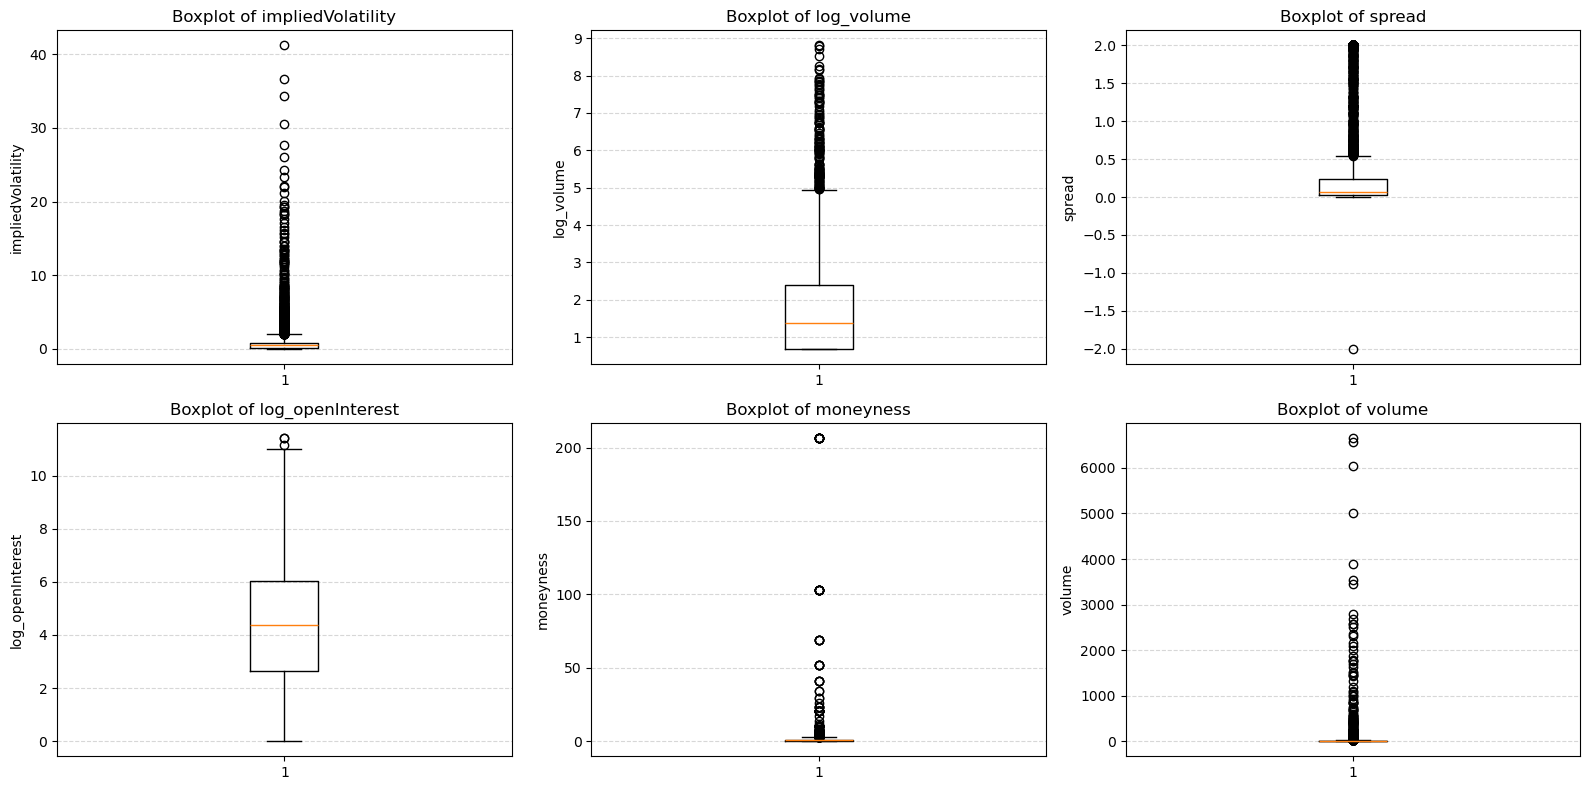

In [8]:
# Refined boxplot generation for key features
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 8))
axes = axes.flatten()

# Features to inspect: IV, Volume, Spread, Open Interest, Moneyness
features_to_plot = ['impliedVolatility', 'log_volume', 'spread', 'log_openInterest', 'moneyness', 'volume']

outlier_summary = outlier_summary_iqr(df_call[features_to_plot]) 
print("Outlier Summary (IQR Method):") 
print(outlier_summary.round(4))

for i, col in enumerate(features_to_plot):
    axes[i].boxplot(df_call[col].dropna(), vert=True)
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

- IV has some values going widely high
- Spread & volume have negative values -> need to remove
- Moneyness with values above 206.55 are likely unrealistic
- Moneyness is highly skewed, we can log it

#### Basic Filtering

In [9]:
# Cap IV values 
df_call = df_call[
    (df_call["impliedVolatility"] > 0) &
    (df_call["impliedVolatility"] < 10)  
]

# Remove negative spread
df_call = df_call[
    (df_call["spread"] > 0)
]

# Cap moneyness for reasonable range
df_call = df_call[
    (df_call["moneyness"] > 0.05) &
    (df_call["moneyness"] < 2)
]

# Remove negative volume
df_call = df_call[df_call["volume"] > 0]

More Vizualizations

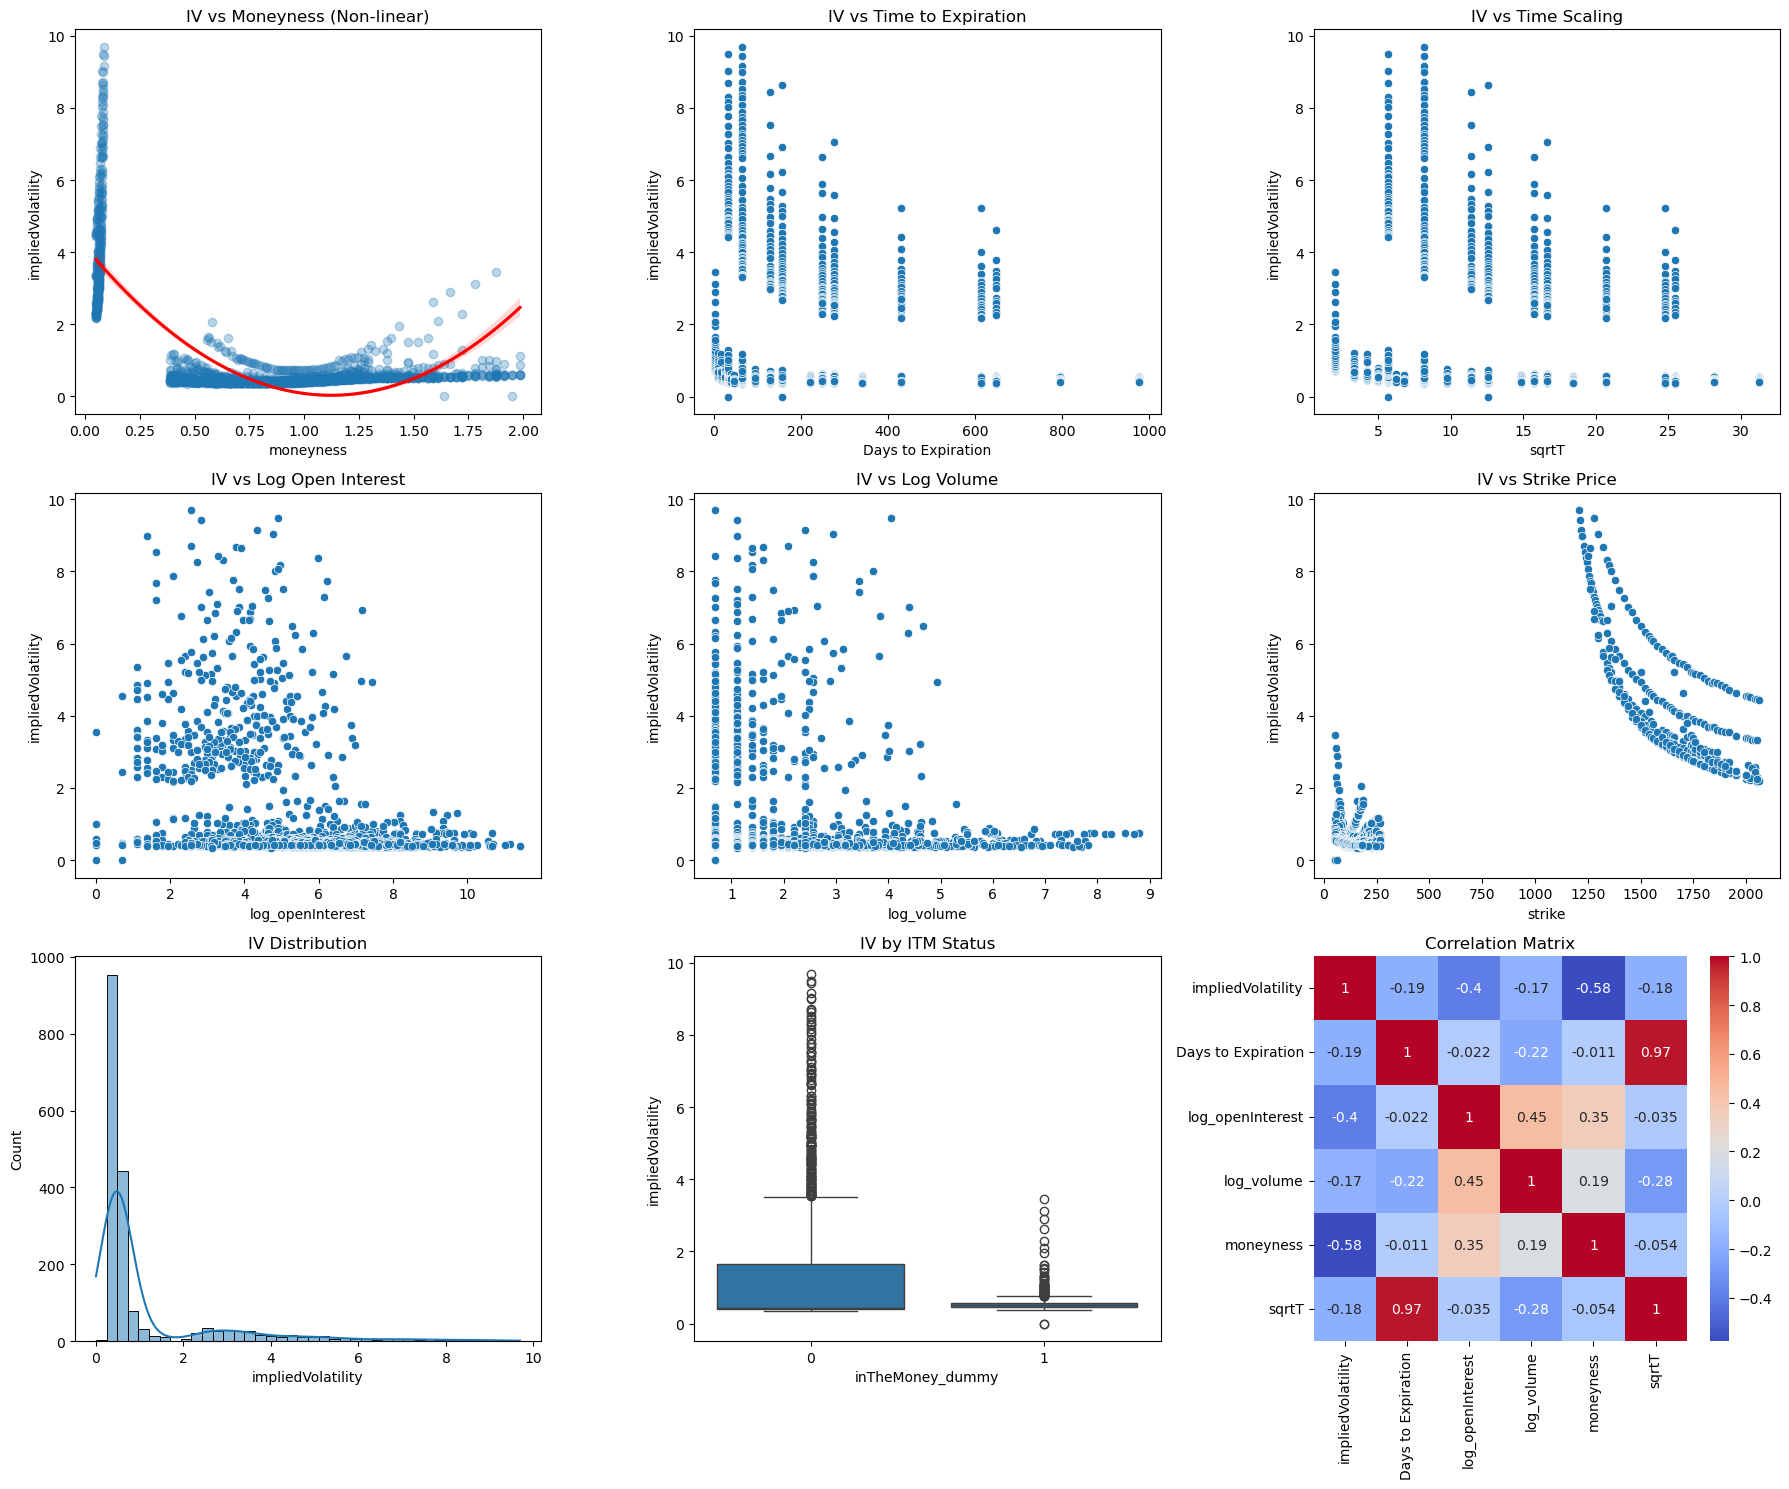

In [10]:
# Set up a 3x3 grid for visualizations
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# --- Relationships ---
sns.regplot(ax=axes[0, 0], data=df_call, x='moneyness', y='impliedVolatility', scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, order=2)
axes[0, 0].set_title('IV vs Moneyness (Non-linear)')

sns.scatterplot(ax=axes[0, 1], data=df_call, x="Days to Expiration", y="impliedVolatility")
axes[0, 1].set_title("IV vs Time to Expiration")

sns.scatterplot(ax=axes[0, 2], data=df_call, x="sqrtT", y="impliedVolatility")
axes[0, 2].set_title("IV vs Time Scaling")

sns.scatterplot(ax=axes[1, 0], data=df_call, x="log_openInterest", y="impliedVolatility")
axes[1, 0].set_title("IV vs Log Open Interest")

sns.scatterplot(ax=axes[1, 1], data=df_call, x="log_volume", y="impliedVolatility")
axes[1, 1].set_title("IV vs Log Volume")

# --- Strike and Liquidity ---
sns.scatterplot(ax=axes[1, 2], data=df_call, x="strike", y="impliedVolatility")
axes[1, 2].set_title("IV vs Strike Price")

# --- Distributions ---
sns.histplot(ax=axes[2, 0], data=df_call, x="impliedVolatility", bins=40, kde=True)
axes[2, 0].set_title("IV Distribution")

sns.boxplot(ax=axes[2, 1], data=df_call, x="inTheMoney_dummy", y="impliedVolatility")
axes[2, 1].set_title("IV by ITM Status")

# --- Correlation ---
corr_cols = ["impliedVolatility", "Days to Expiration", "log_openInterest", "log_volume", "moneyness", "sqrtT"]
corr = df_call[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[2, 2])
axes[2, 2].set_title("Correlation Matrix")


# Adjust layout for better visualization
plt.tight_layout()
plt.show()

- IV increases as options move away from ATM -> Moneyness is a key driver of IV
- Short maturities show more dispersion
- log_openInterest has high correlation with log_volume (0,45) as both capture liquidity; they both have slight negative - relationship vs spread → might partially redundant
- Clear difference between ITM and OTM boxplots

Overall, relationships are nonlinear, we could expect Linear models will perform poorly.

In [11]:
# Generate 3D scatter plot
fig_3d = px.scatter_3d(
    df_call,
    x='moneyness',
    y='Days to Expiration',
    z='impliedVolatility',
    color='impliedVolatility',
    size='impliedVolatility',
    color_continuous_scale='RdBu',
    title='3D Visualization of IV (Moneyness vs Expiry)',
    labels={
        'moneyness': 'Moneyness (S/K)',
        'Days to Expiration': 'Days to Expiration',
        'impliedVolatility': 'IV'
    }
)

fig_3d.update_layout(scene=dict(
    xaxis_title='Moneyness',
    yaxis_title='Days to Expiration',
    zaxis_title='IV'
))

fig_3d.show()

For short-dated options, there are a lot of curvatures in terms of IV, for long dated options, it flattens out.

In [12]:
# Advanced feature engineering
df_call["moneyness_sq"] = df_call["moneyness"]**2  # Captures volatility smile (U-shape)

### 2.1 Implied Volatility Model

In [13]:
# Select features
feature_iv = [
    "moneyness",
    "moneyness_sq",   
    "log_moneyness",
    "Days to Expiration",
    "sqrtT",
    "log_volume","log_openInterest"
]
# moneyness and Days to Expiration are core driver of IV
# liquidity variables such as volume is included but are not expected to be primary drivers of implied volatility
# spread is excluded because it reflects market liquidity, not meaningful when we try to predict how the market expects future risk -> including it may introduce noise and weaken the model’s generalization
# inTheMoney_dummy is redundant with moneyness

In [14]:
X_iv = df_call[feature_iv]
y_iv = df_call["impliedVolatility"]

y_iv_bins = pd.qcut(y_iv, q=10, labels=False, duplicates="drop")

# Train-test split with stratification on IV bins
X_iv_train, X_iv_test, y_iv_train, y_iv_test = train_test_split(
    X_iv, y_iv,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_iv_bins
)

print("Train shape:", X_iv_train.shape)
print("Test shape :", X_iv_test.shape)

Train shape: (1484, 7)
Test shape : (372, 7)


A set of regression models was implemented to predict implied volatility, including Linear Regression as a baseline, Random Forest, XGBoost and LightGBM as tree-based methods, and a feedforward neural network for capturing nonlinear relationships. Tree-based models are well-suited for tabular financial data, while the neural network provides additional flexibility to approximate complex patterns such as the volatility smile.

In [15]:
# Scale features for models that require it (LR + NN)
scaler = StandardScaler()

X_iv_train_scaled = scaler.fit_transform(X_iv_train)
X_iv_test_scaled = scaler.transform(X_iv_test)

Train Models

Results will be summoned up by function evaluate_regression which was defined in part 1

In [24]:
results_iv = []
best_models_iv = {}

# Linear Regression
lr_iv = LinearRegression()
lr_iv.fit(X_iv_train_scaled, y_iv_train)

y_pred = lr_iv.predict(X_iv_test_scaled)
metrics = evaluate_regression(y_iv_test, y_pred)

results_iv.append({"Model": "Linear Regression", **metrics})
best_models_iv["Linear Regression"] = lr_iv

# Random Forest
rf_iv = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_iv.fit(X_iv_train, y_iv_train)

y_pred = rf_iv.predict(X_iv_test)
metrics = evaluate_regression(y_iv_test, y_pred)

results_iv.append({"Model": "Random Forest", **metrics})
best_models_iv["Random Forest"] = rf_iv

# XGBoost
xgb_iv = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_iv.fit(X_iv_train, y_iv_train)

y_pred = xgb_iv.predict(X_iv_test)
metrics = evaluate_regression(y_iv_test, y_pred)

results_iv.append({"Model": "XGBoost", **metrics})
best_models_iv["XGBoost"] = xgb_iv

# LightGBM
lgbm_iv = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lgbm_iv.fit(X_iv_train, y_iv_train)

y_pred = lgbm_iv.predict(X_iv_test)
metrics = evaluate_regression(y_iv_test, y_pred)

results_iv.append({"Model": "LightGBM", **metrics})
best_models_iv["LightGBM"] = lgbm_iv

# Neural Network (keras)
nn_model_iv = keras.Sequential([
    layers.Input(shape=(X_iv_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

nn_model_iv.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = nn_model_iv.fit(
    X_iv_train_scaled,
    y_iv_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    verbose=0,
    callbacks=[early_stopping]
)

# Predict
y_pred = nn_model_iv.predict(X_iv_test_scaled, verbose=0).ravel()

metrics = evaluate_regression(y_iv_test, y_pred)

results_iv.append({"Model": "Neural Network", **metrics})
best_models_iv["Neural Network"] = nn_model_iv

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000239 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1103
[LightGBM] [Info] Number of data points in the train set: 1484, number of used features: 7
[LightGBM] [Info] Start training from score 1.150194


In [25]:
results_iv_df = pd.DataFrame(results_iv).sort_values("RMSE").reset_index(drop=True)

print("\nFinal Model Comparison:")
print(results_iv_df.round(6))

best_model_iv_name = results_iv_df.loc[0, "Model"]
best_model_iv = best_models_iv[best_model_iv_name]

# Generate predictions using the correct input format
if best_model_iv_name == "Linear Regression" or best_model_iv_name == "Neural Network":
    y_pred_best_iv = best_model_iv.predict(X_iv_test_scaled, verbose=0).ravel()
else:
    y_pred_best_iv = best_model_iv.predict(X_iv_test)

y_pred_best_iv = np.maximum(y_pred_best_iv, 0.0)


Final Model Comparison:
               Model       MSE      RMSE       MAE        R2
0      Random Forest  0.010892  0.104364  0.040203  0.995317
1            XGBoost  0.015041  0.122643  0.050565  0.993533
2           LightGBM  0.029124  0.170659  0.071699  0.987477
3     Neural Network  0.031577  0.177700  0.094396  0.986423
4  Linear Regression  0.474694  0.688980  0.401180  0.795897


Random Forest was the best model here, with XGBoost ranked 2nd. This performance is expected because they are particularly strong for this type of regression task. As we know RF & XGBoost are ensemble models that work well for datasets with complex, non-linear relationships like financial data. They don’t require feature scaling, and their ability to capture interactions between features allows them to model the volatility data effectively. 

Boosting models like XGBoost & LightGBM could do better if we adjust their hyperparameters. They can sometimes be more sensitive to overfitting if not properly tuned.

Neural networks require extensive tuning to perform well on tabular data, and their complexity might not be needed for relatively simpler datasets like this one. Tree-based models generally outperform Neural Networks on tasks involving structured/tabular data.

Vizualizations on Best Model

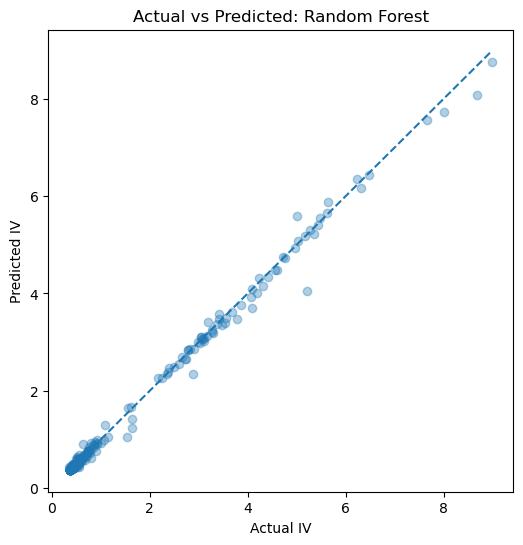

In [26]:
# Plot: Actual vs Predicted plot
plt.figure(figsize=(6, 6))
plt.scatter(y_iv_test, y_pred_best_iv, alpha=0.35)
plt.xlabel("Actual IV")
plt.ylabel("Predicted IV")
plt.title(f"Actual vs Predicted: {best_model_iv_name}")

min_val = min(np.min(y_iv_test), np.min(y_pred_best_iv))
max_val = max(np.max(y_iv_test), np.max(y_pred_best_iv))
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

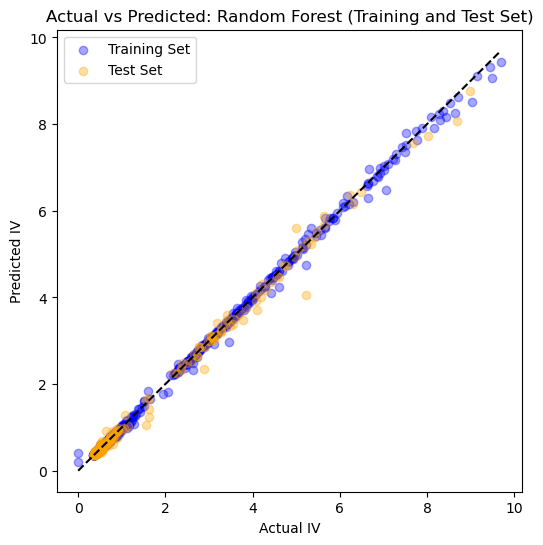

In [27]:
# CHECK OVERFITTING ON BEST MODEL
# Generate predictions for training data as well
y_pred_train_iv = best_model_iv.predict(X_iv_train).ravel()
y_pred_train_iv = np.maximum(y_pred_train_iv, 0.0)  # Ensure no negative values for IV

# Plot: Actual vs Predicted for Training and Test sets
plt.figure(figsize=(6, 6))

# Plot for training data
plt.scatter(y_iv_train, y_pred_train_iv, alpha=0.35, label='Training Set', color='blue')

# Plot for test data
plt.scatter(y_iv_test, y_pred_best_iv, alpha=0.35, label='Test Set', color='orange')

# Line of perfect predictions
min_val = min(np.min(y_iv_train), np.min(y_iv_test), np.min(y_pred_train_iv), np.min(y_pred_best_iv))
max_val = max(np.max(y_iv_train), np.max(y_iv_test), np.max(y_pred_train_iv), np.max(y_pred_best_iv))
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color='black')

# Add labels and title
plt.xlabel("Actual IV")
plt.ylabel("Predicted IV")
plt.title(f"Actual vs Predicted: {best_model_iv_name} (Training and Test Set)")
plt.legend()
plt.show()

Both training and test predictions lie closely along the diagonal line. This indicates that the model generalizes well to new data, no overfitting showed.

#### Feature Importance
Techniques used: Permutation Importance & SHAP
- Permutation Importance: Quick, provides an overall view of feature importance based on performance.
- SHAP: Offers precise & specific feature contributions, useful for understanding both global feature importance and the individual predictions made by the model.

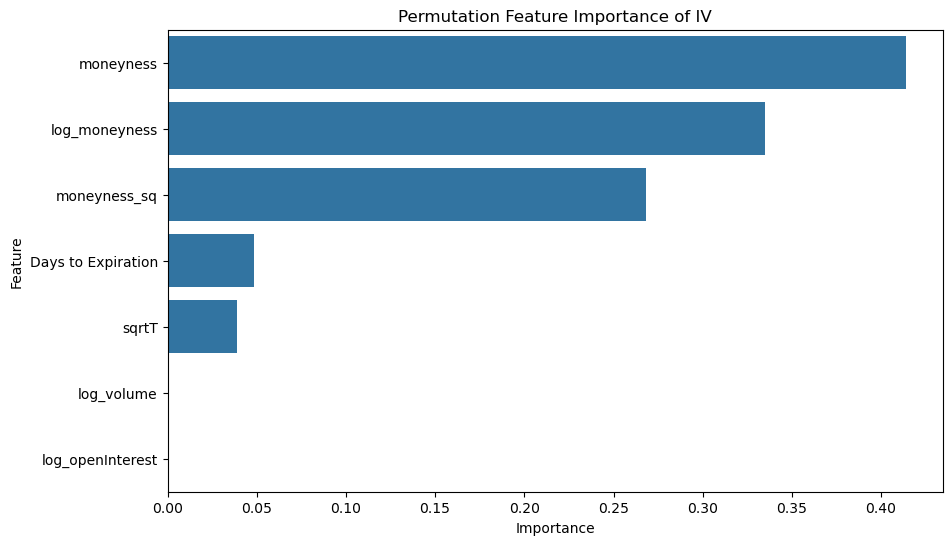

              Feature  Importance
0           moneyness    0.413741
2       log_moneyness    0.334930
1        moneyness_sq    0.268207
3  Days to Expiration    0.048657
4               sqrtT    0.039173
5          log_volume    0.000958
6    log_openInterest    0.000068


In [28]:
# Calculate permutation importance for best model
perm_importance_iv = permutation_importance(best_model_iv, X_iv_test, y_iv_test, n_repeats=10, random_state=RANDOM_STATE)

# Create a DataFrame for permutation importance
perm_importance_iv_df = pd.DataFrame({
    "Feature": X_iv_test.columns,
    "Importance": perm_importance_iv.importances_mean  # Mean importance across repeats
})

# Sort by importance
perm_importance_iv_df = perm_importance_iv_df.sort_values(by="Importance", ascending=False)

# Plot the permutation importance
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=perm_importance_iv_df)
plt.title("Permutation Feature Importance of IV")
plt.show()

# Print the result
print(perm_importance_iv_df)

C:\Users\Admin\AppData\Local\Temp\ipykernel_12684\2564436632.py:7: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



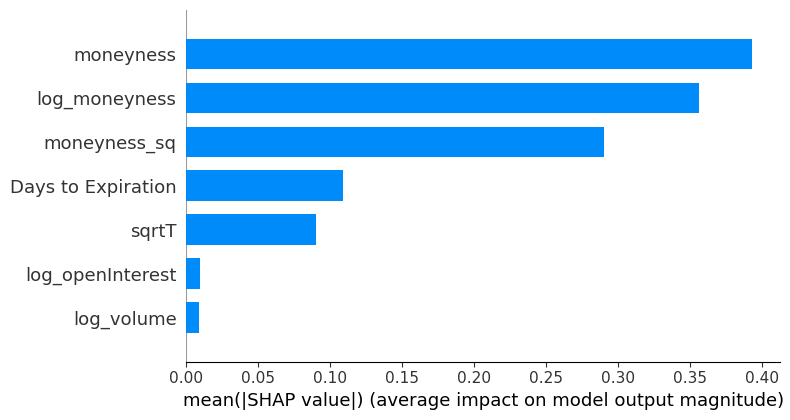

In [29]:
# SHAP Explainer for Random Forest
explainer = shap.TreeExplainer(best_models_iv[best_model_iv_name])
shap_values_iv = explainer.shap_values(X_iv_test)

# Summary plot for global feature importance (SHAP values)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_iv, X_iv_test, plot_type="bar")

From result, log_openInterest has a very low importance score (0.000068), it shows no contribution significantly to the model’s performance. Also, log_volume & log_openInterest have correlation of 0.45 

-> I will try dropping log_openInterest and run model once again to speed up training, reduce overfitting risk, and see if there's potential improvement on performance. 

In [33]:
feature_iv_v2 = [
    "moneyness",
    "moneyness_sq",   
    "log_moneyness",
    "Days to Expiration",
    "sqrtT",
    "log_volume"
]

X_iv_v2 = df_call[feature_iv_v2]
y_iv = df_call["impliedVolatility"]

# Train-test split with stratification on IV bins
X_iv_v2_train, X_iv_v2_test, y_iv_train, y_iv_test = train_test_split(
    X_iv_v2, y_iv,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_iv_bins
)

# Scale features for models that require it (LR + NN)
scaler = StandardScaler()

X_iv_v2_train_scaled = scaler.fit_transform(X_iv_v2_train)
X_iv_v2_test_scaled = scaler.transform(X_iv_v2_test)

results_iv_v2 = []
best_models_iv_v2 = {}

# Linear Regression
lr_iv_v2 = LinearRegression()
lr_iv_v2.fit(X_iv_v2_train_scaled, y_iv_train)
y_pred_v2 = lr_iv_v2.predict(X_iv_v2_test_scaled)
metrics = evaluate_regression(y_iv_test, y_pred_v2)
results_iv_v2.append({"Model": "Linear Regression", **metrics})
best_models_iv_v2["Linear Regression"] = lr_iv_v2

# Random Forest (no scaling required)
rf_iv_v2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_iv_v2.fit(X_iv_v2_train, y_iv_train)
y_pred_v2 = rf_iv_v2.predict(X_iv_v2_test)
metrics = evaluate_regression(y_iv_test, y_pred_v2)
results_iv_v2.append({"Model": "Random Forest", **metrics})
best_models_iv_v2["Random Forest"] = rf_iv_v2

# XGBoost (no scaling required)
xgb_iv_v2 = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_iv_v2.fit(X_iv_v2_train, y_iv_train)
y_pred_v2 = xgb_iv_v2.predict(X_iv_v2_test)
metrics = evaluate_regression(y_iv_test, y_pred_v2)
results_iv_v2.append({"Model": "XGBoost", **metrics})
best_models_iv_v2["XGBoost"] = xgb_iv_v2

# LightGBM (no scaling required)
lgbm_iv_v2 = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lgbm_iv_v2.fit(X_iv_v2_train, y_iv_train)
y_pred_v2 = lgbm_iv_v2.predict(X_iv_v2_test)
metrics = evaluate_regression(y_iv_test, y_pred_v2)
results_iv_v2.append({"Model": "LightGBM", **metrics})
best_models_iv_v2["LightGBM"] = lgbm_iv_v2

# Neural Network (requires scaling)
nn_model_iv_v2 = keras.Sequential([
    layers.Input(shape=(X_iv_v2_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

nn_model_iv_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = nn_model_iv_v2.fit(
    X_iv_v2_train_scaled,
    y_iv_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    verbose=0,
    callbacks=[early_stopping]
)

# Predict
y_pred_v2 = nn_model_iv_v2.predict(X_iv_v2_test_scaled, verbose=0).ravel()
metrics = evaluate_regression(y_iv_test, y_pred_v2)
results_iv_v2.append({"Model": "Neural Network", **metrics})
best_models_iv_v2["Neural Network"] = nn_model_iv_v2

# Final comparison of models after dropping 'log_openInterest'
results_iv_v2_df = pd.DataFrame(results_iv_v2).sort_values("RMSE").reset_index(drop=True)

print("\nModel Comparison after drop log_openInterest:")
print(results_iv_v2_df.round(6))

best_model_iv_v2_name = results_iv_v2_df.loc[0, "Model"]
best_model_iv_v2 = best_models_iv_v2[best_model_iv_v2_name]

# Generate predictions using the correct input format
if best_model_iv_v2_name == "Linear Regression" or best_model_iv_v2_name == "Neural Network":
    y_pred_best_iv_v2 = best_model_iv_v2.predict(X_iv_v2_test_scaled, verbose=0).ravel()
else:
    y_pred_best_iv_v2 = best_model_iv_v2.predict(X_iv_v2_test)

y_pred_best_iv_v2 = np.maximum(y_pred_best_iv_v2, 0.0)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000263 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 848
[LightGBM] [Info] Number of data points in the train set: 1484, number of used features: 6
[LightGBM] [Info] Start training from score 1.150194

Model Comparison after drop log_openInterest:
               Model       MSE      RMSE       MAE        R2
0      Random Forest  0.009674  0.098356  0.039170  0.995841
1            XGBoost  0.015510  0.124540  0.047643  0.993331
2     Neural Network  0.022190  0.148963  0.077612  0.990459
3           LightGBM  0.027778  0.166668  0.064529  0.988056
4  Linear Regression  0.479763  0.692649  0.407362  0.793717


In [34]:
# Reprint the initial result version (before drop log_openInterest) to compare
print(results_iv_df.round(6))

               Model       MSE      RMSE       MAE        R2
0      Random Forest  0.010892  0.104364  0.040203  0.995317
1            XGBoost  0.015041  0.122643  0.050565  0.993533
2           LightGBM  0.029124  0.170659  0.071699  0.987477
3     Neural Network  0.031577  0.177700  0.094396  0.986423
4  Linear Regression  0.474694  0.688980  0.401180  0.795897


The models showed positive or neutral performance changes after dropping log_openInterest, confirming that this feature was either non-informative or redundant for these models.

XGBoost showed a slight drop but still performed well.

### 2.2 Spread Model


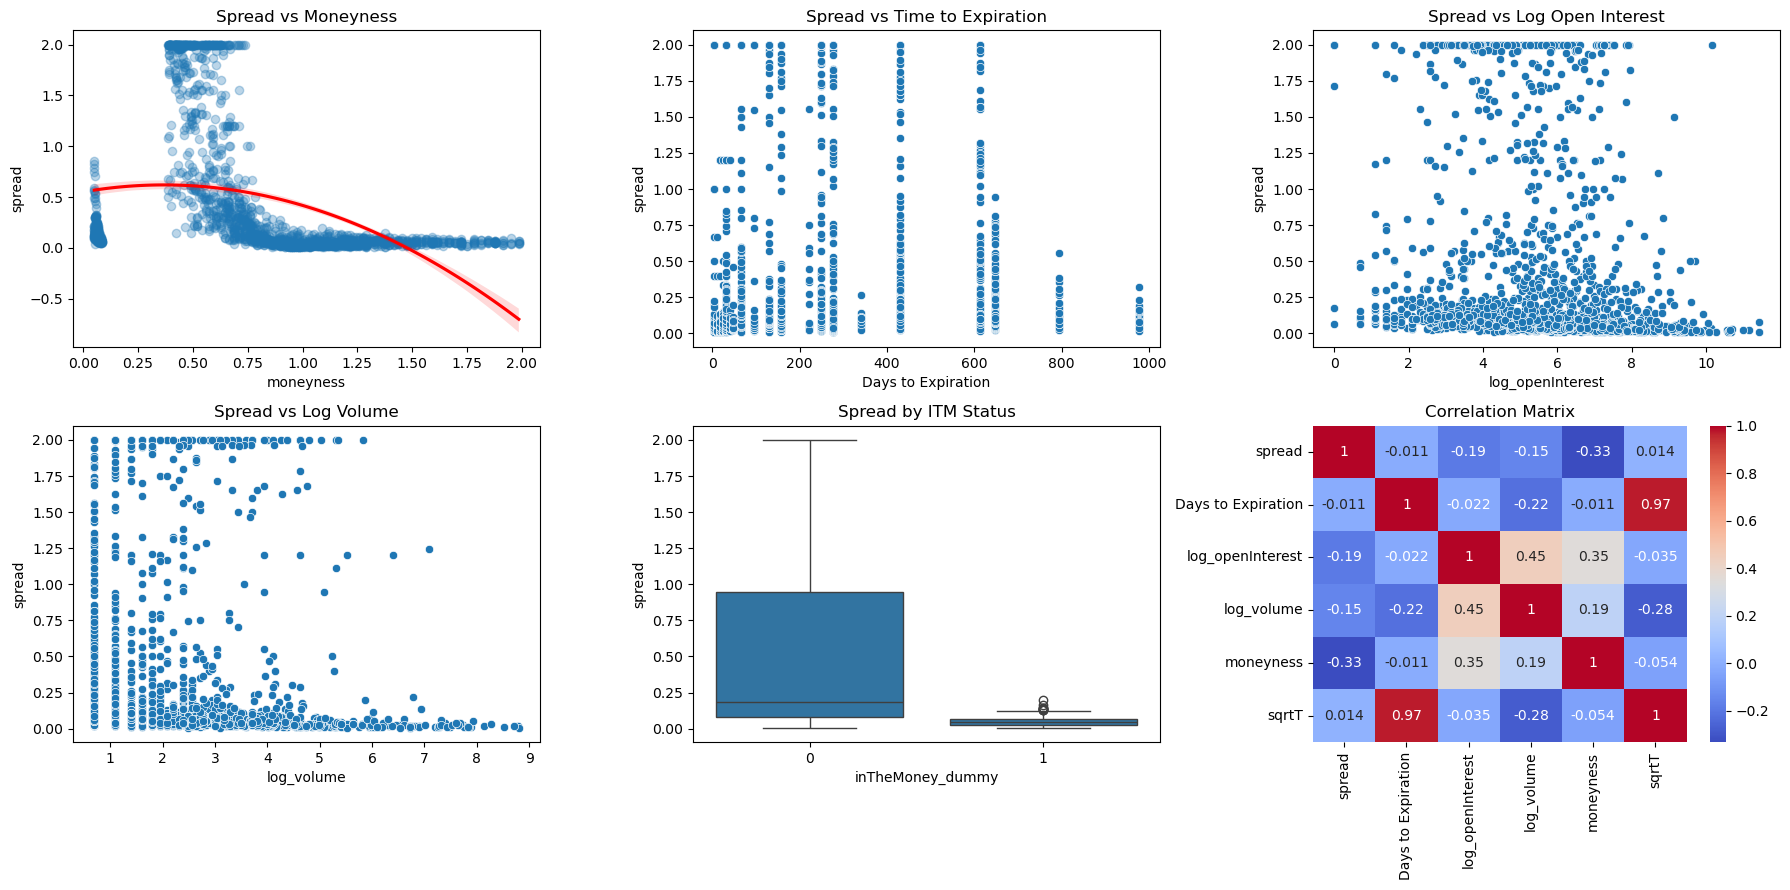

C:\Users\Admin\AppData\Local\Temp\ipykernel_12684\1109101961.py:37: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Admin\AppData\Local\Temp\ipykernel_12684\1109101961.py:38: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Admin\AppData\Local\Temp\ipykernel_12684\1109101961.py:45: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Admin\AppData\Local\Temp\ipykernel_12684\1109101961.py:46: FutureWarning:

Series.__g

In [35]:
# Set up a 3x3 grid for visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

sns.regplot(ax=axes[0, 0], data=df_call, x='moneyness', y='spread', scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, order=2)
axes[0, 0].set_title('Spread vs Moneyness')

sns.scatterplot(ax=axes[0, 1], data=df_call, x="Days to Expiration", y="spread")
axes[0, 1].set_title("Spread vs Time to Expiration")

sns.scatterplot(ax=axes[0, 2], data=df_call, x="log_openInterest", y="spread")
axes[0, 2].set_title("Spread vs Log Open Interest")

sns.scatterplot(ax=axes[1, 0], data=df_call, x="log_volume", y="spread")
axes[1, 0].set_title("Spread vs Log Volume")


sns.boxplot(ax=axes[1, 1], data=df_call, x="inTheMoney_dummy", y="spread")
axes[1,1].set_title("Spread by ITM Status")

# --- Correlation ---
corr_cols = ["spread", "Days to Expiration", "log_openInterest", "log_volume", "moneyness", "sqrtT"]
corr = df_call[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[1, 2])
axes[1, 2].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

# Relationships and correlations
relationships = []

# --- Relationships ---
moneyness_vs_spread = sm.OLS(df_call['spread'], sm.add_constant(df_call['moneyness'])).fit()
relationships.append({
    'Feature 1': 'Moneyness', 'Feature 2': 'Spread',
    'Correlation': df_call['moneyness'].corr(df_call['spread']),
    'Regression Coeff': moneyness_vs_spread.params[1],
    'p-value': moneyness_vs_spread.pvalues[1]
})

days_to_expiration_vs_spread = sm.OLS(df_call['spread'], sm.add_constant(df_call['Days to Expiration'])).fit()
relationships.append({
    'Feature 1': 'Days to Expiration', 'Feature 2': 'Spread',
    'Correlation': df_call['Days to Expiration'].corr(df_call['spread']),
    'Regression Coeff': days_to_expiration_vs_spread.params[1],
    'p-value': days_to_expiration_vs_spread.pvalues[1]
})

time_scaling_vs_spread = sm.OLS(df_call['spread'], sm.add_constant(df_call['sqrtT'])).fit()
relationships.append({
    'Feature 1': 'Time Scaling', 'Feature 2': 'Spread',
    'Correlation': df_call['sqrtT'].corr(df_call['spread']),
    'Regression Coeff': time_scaling_vs_spread.params[1],
    'p-value': time_scaling_vs_spread.pvalues[1]
})

log_open_interest_vs_spread = sm.OLS(df_call['spread'], sm.add_constant(df_call['log_openInterest'])).fit()
relationships.append({
    'Feature 1': 'Log Open Interest', 'Feature 2': 'Spread',
    'Correlation': df_call['log_openInterest'].corr(df_call['spread']),
    'Regression Coeff': log_open_interest_vs_spread.params[1],
    'p-value': log_open_interest_vs_spread.pvalues[1]
})

log_volume_vs_spread = sm.OLS(df_call['spread'], sm.add_constant(df_call['log_volume'])).fit()
relationships.append({
    'Feature 1': 'Log Volume', 'Feature 2': 'Spread',
    'Correlation': df_call['log_volume'].corr(df_call['spread']),
    'Regression Coeff': log_volume_vs_spread.params[1],
    'p-value': log_volume_vs_spread.pvalues[1]
})

log_volume_vs_spread = sm.OLS(df_call['spread'], sm.add_constant(df_call['inTheMoney_dummy'])).fit()
relationships.append({
    'Feature 1': 'inTheMoney dummy', 'Feature 2': 'Spread',
    'Correlation': df_call['inTheMoney_dummy'].corr(df_call['spread']),
    'Regression Coeff': log_volume_vs_spread.params[1],
    'p-value': log_volume_vs_spread.pvalues[1]
})

# Convert results into a DataFrame
relationships_df = pd.DataFrame(relationships)

In [36]:
relationships_df

,Feature 1,Feature 2,Correlation,Regression Coeff,p-value
0,Moneyness,Spread,-0.332723,-0.462734,3.232777e-49
1,Days to Expiration,Spread,-0.010955,-0.000031,6.371875e-01
2,Time Scaling,Spread,0.013556,0.001173,5.594720e-01
3,Log Open Interest,Spread,-0.187275,-0.063430,4.129988e-16
4,Log Volume,Spread,-0.153081,-0.062362,3.366521e-11
5,inTheMoney dummy,Spread,-0.385437,-0.543720,8.562222e-67


There is a moderate negative correlation between moneyness and spread (-0.33). This suggests that as options become more ITM (higher moneyness), their spread tends to decrease. The correlation with inTheMoney also points out the same thing. This makes sense because ITM options are generally more liquid and less risky, so they have narrower spreads. Very small p-value -> this relationship is highly significant.

Moderate negative correlations between log_openInterest or log_volume vs spread (-0.18 & -0.15) suggest that higher liquidity is associated with narrower spreads.

Days to expiration and time scaling (sqrtT) do not seem to contribute significantly to explaining the spread.



In [37]:
# Generate the interactive 2D scatter plot
fig = px.scatter(
    df_call,
    x='moneyness',
    y='Days to Expiration',
    size='spread',
    color='spread',
    color_continuous_scale='RdBu',
    title="Bid-Ask Spread (Low Moneyness & Low Time to Expiration)",
    labels={
        'moneyness': 'Moneyness (Stock Price / Strike)',
        'Days to Expiration': 'Days to Expiration',
        'spread': 'Spread'
    },
    hover_data=['strike', 'impliedVolatility', 'volume', 'openInterest']
)

fig.update_layout(
    xaxis_title='Moneyness (Stock Price / Strike)',
    yaxis_title='Days to Expiration',
    legend_title='Spread Size'
)

fig.show()

- spread is particularly large for low moneyness
- options with longer DTE tend to have lower spreads compared to short-term options, which is consistent with the financial concept that options closer to expiration are more volatile, leading to wider spreads for market makers.

In [38]:
# Generate 3D scatter plot for the filtered data
fig_3d = px.scatter_3d(
    df_call,
    x='moneyness',
    y='Days to Expiration',
    z='spread',
    color='spread',
    size='spread',
    color_continuous_scale='RdBu',
    title='3D Visualization of Option Spread (Moneyness vs Expiry)',
    labels={
        'moneyness': 'Moneyness (S/K)',
        'Days to Expiration': 'Days to Expiration',
        'spread': 'Bid-Ask Spread'
    }
)

fig_3d.update_layout(scene=dict(
    xaxis_title='Moneyness',
    yaxis_title='Days to Expiration',
    zaxis_title='Spread'
))

fig_3d.show()

#### Modelling

In [39]:
# Select features
feature_spread = [
    "moneyness",
    "moneyness_sq",   
    "log_moneyness",
    "Days to Expiration",
    "sqrtT",
    "log_volume", "log_openInterest"
]
X_spread = df_call[feature_spread]
y_spread = df_call['spread']

# create bins for target y
y_spread_bins = pd.qcut(y_spread, q=10, labels=False, duplicates="drop")

# Train-test split with stratification on Spread bins
X_spread_train, X_spread_test, y_spread_train, y_spread_test = train_test_split(
    X_spread, y_spread,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_spread_bins
)

print("Train shape:", X_spread_train.shape)
print("Test shape :", X_spread_test.shape)

Train shape: (1484, 7)
Test shape : (372, 7)


In [40]:
# Scale features for models that require it (LR, SVR, NN)
scaler = StandardScaler()

X_spread_train_scaled = scaler.fit_transform(X_spread_train)
X_spread_test_scaled = scaler.transform(X_spread_test)

In [41]:
# List to store results and models
results_spread = []
best_models_spread = {}

# Linear Regression
lr_spread = LinearRegression()
lr_spread.fit(X_spread_train_scaled, y_spread_train)

y_pred_spread = lr_spread.predict(X_spread_test_scaled)
metrics_spread = evaluate_regression(y_spread_test, y_pred_spread)

results_spread.append({"Model": "Linear Regression", **metrics_spread})
best_models_spread["Linear Regression"] = lr_spread

# Random Forest
rf_spread = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_spread.fit(X_spread_train, y_spread_train)

y_pred_spread = rf_spread.predict(X_spread_test)
metrics_spread = evaluate_regression(y_spread_test, y_pred_spread)

results_spread.append({"Model": "Random Forest", **metrics_spread})
best_models_spread["Random Forest"] = rf_spread

# XGBoost
xgb_spread = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_spread.fit(X_spread_train, y_spread_train)

y_pred_spread = xgb_spread.predict(X_spread_test)
metrics_spread = evaluate_regression(y_spread_test, y_pred_spread)

results_spread.append({"Model": "XGBoost", **metrics_spread})
best_models_spread["XGBoost"] = xgb_spread

# LightGBM
lgbm_spread = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lgbm_spread.fit(X_spread_train, y_spread_train)

y_pred_spread = lgbm_spread.predict(X_spread_test)
metrics_spread = evaluate_regression(y_spread_test, y_pred_spread)

results_spread.append({"Model": "LightGBM", **metrics_spread})
best_models_spread["LightGBM"] = lgbm_spread

# Gradient Boosting
gb_spread = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=RANDOM_STATE
)

gb_spread.fit(X_spread_train, y_spread_train)

y_pred_spread = gb_spread.predict(X_spread_test)
metrics_spread = evaluate_regression(y_spread_test, y_pred_spread)

results_spread.append({"Model": "Gradient Boosting", **metrics_spread})
best_models_spread["Gradient Boosting"] = gb_spread

# Support Vector Regression (SVR)
svr_spread = SVR(kernel="rbf", C=10, epsilon=0.1)

svr_spread.fit(X_spread_train_scaled, y_spread_train)

y_pred_spread = svr_spread.predict(X_spread_test_scaled)
metrics_spread = evaluate_regression(y_spread_test, y_pred_spread)

results_spread.append({"Model": "SVR", **metrics_spread})
best_models_spread["SVR"] = svr_spread

# Neural Network (Keras)
nn_spread_model = keras.Sequential([
    layers.Input(shape=(X_spread_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

nn_spread_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

early_stopping_spread = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history_spread = nn_spread_model.fit(
    X_spread_train_scaled,
    y_spread_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    verbose=0,
    callbacks=[early_stopping_spread]
)

# Predict
y_pred_spread = nn_spread_model.predict(X_spread_test_scaled, verbose=0).ravel()

metrics_spread = evaluate_regression(y_spread_test, y_pred_spread)

results_spread.append({"Model": "Neural Network", **metrics_spread})
best_models_spread["Neural Network"] = nn_spread_model

# Store results
results_spread_df = pd.DataFrame(results_spread).sort_values("RMSE").reset_index(drop=True)

# Print model comparison
print("\nFinal Model Comparison for Spread Prediction:")
print(results_spread_df.round(6))

# Select the best model
best_model_spread_name = results_spread_df.loc[0, "Model"]
best_model_spread = best_models_spread[best_model_spread_name]

# Generate predictions using the best model
if best_model_spread_name == "Linear Regression" or best_model_spread_name == "Neural Network" or best_model_spread_name == "SVR":
    y_pred_best_spread = best_model_spread.predict(X_spread_test_scaled, verbose=0).ravel()
else:
    y_pred_best_spread = best_model_spread.predict(X_spread_test)

y_pred_best_spread = np.maximum(y_pred_best_spread, 0.0)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000191 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1113
[LightGBM] [Info] Number of data points in the train set: 1484, number of used features: 7
[LightGBM] [Info] Start training from score 0.424494

Final Model Comparison for Spread Prediction:
               Model       MSE      RMSE       MAE        R2
0            XGBoost  0.045024  0.212188  0.091782  0.893592
1           LightGBM  0.047474  0.217886  0.099249  0.887800
2      Random Forest  0.049440  0.222351  0.096963  0.883155
3  Gradient Boosting  0.054172  0.232748  0.103469  0.871972
4     Neural Network  0.070401  0.265333  0.139660  0.833615
5                SVR  0.070838  0.266153  0.151668  0.832584
6  Linear Regression  0.141305  0.375905  0.271475  0.666043


Vizualize the performance of best model

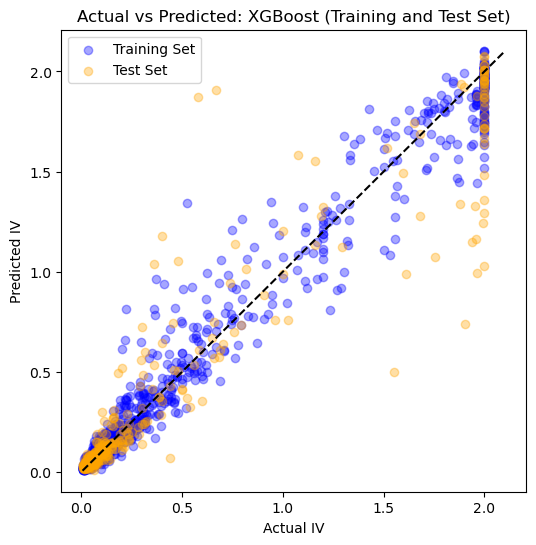

In [42]:
# Generate predictions for training data
y_pred_train_spread = best_model_spread.predict(X_spread_train).ravel()
y_pred_train_spread = np.maximum(y_pred_train_spread, 0.0)  # Ensure no negative values for IV

# Plot: Actual vs Predicted for Training and Test sets
plt.figure(figsize=(6, 6))

# Plot for training data
plt.scatter(y_spread_train, y_pred_train_spread, alpha=0.35, label='Training Set', color='blue')

# Plot for test data
plt.scatter(y_spread_test, y_pred_best_spread, alpha=0.35, label='Test Set', color='orange')

# Line of perfect predictions
min_val = min(np.min(y_spread_train), np.min(y_spread_test), np.min(y_pred_train_spread), np.min(y_pred_best_spread))
max_val = max(np.max(y_spread_train), np.max(y_spread_test), np.max(y_pred_train_spread), np.max(y_pred_best_spread))
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color='black')

# Add labels and title
plt.xlabel("Actual IV")
plt.ylabel("Predicted IV")
plt.title(f"Actual vs Predicted: {best_model_spread_name} (Training and Test Set)")
plt.legend()
plt.show()

There is evidence that it was overfitted. We will check a bit closer

In [43]:
metrics_spread_train= evaluate_regression(y_spread_train, y_pred_train_spread)

print(f"Training metrics for {best_model_spread_name}: {metrics_spread_train}")
print(f"Testing metrics for {best_model_spread_name}: {results_spread_df.loc[results_spread_df['Model'] == best_model_spread_name].iloc[0, 1:].to_dict()}")


Training metrics for XGBoost: {'MSE': 0.00879900151143738, 'RMSE': np.float64(0.09380299308357586), 'MAE': 0.04828890321146092, 'R2': 0.9794717462545129}
Testing metrics for XGBoost: {'MSE': 0.04502372318601764, 'RMSE': 0.21218794307410033, 'MAE': 0.09178194027248804, 'R2': 0.8935918519025542}


The test RMSE is much higher than the training RMSE, and the R² drops noticeably between training and testing

-> Possible Solutions for XGBoost:
- adjust regularization parameters like gamma, lambda, or alpha to reduce model complexity
- add early stopping during training to stop the model from learning too much and memorizing the training data
- lower the number of trees (n_estimators) or reduce the depth of the trees (max_depth) to make the model simpler
- use cross-validation to better estimate the model's performance and detect overfitting more accurately
- remove irrelevant or highly correlated features, which can cause overfitting by introducing unnecessary complexity to the model

C:\Users\Admin\AppData\Local\Temp\ipykernel_12684\3492569941.py:15: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



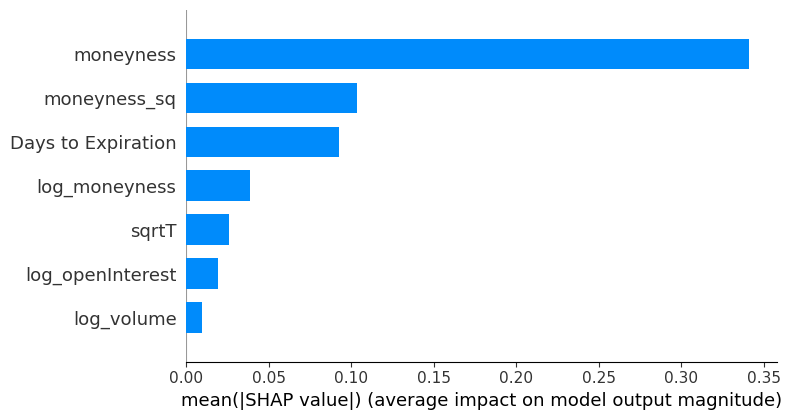

In [44]:
# Create a SHAP explainer for the tree-based model (e.g., XGBoost)
explainer = shap.TreeExplainer(best_model_spread)

# Select a small random sample of test data for explanation
X_explain_spread = X_spread_test.sample(n=200, random_state=RANDOM_STATE)

# Compute SHAP values for the selected sample
shap_values_spread = explainer.shap_values(X_explain_spread)

# Get the feature names for plotting
feature_names_spread = X_spread_test.columns.tolist()

# SHAP Summary Plot for global feature importance (Bar plot)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_spread, X_explain_spread, plot_type="bar", color_bar_label="Feature Importance")
plt.show()

High SHAP value for moneyness means it is a key driver for predicting bid-ask spread. Options with higher moneyness are likely to exhibit tighter spreads.

DTE plays a significant role in options pricing and spreads. As options approach expiration, their time value decreases -> Options with shorter DTE often have larger spreads due to increased gamma risk, as even small price movements in the underlying asset can cause significant changes in the option's value.

The square root of time to expiration, sqrtT, is commonly used to scale volatility and is often a key input for options pricing models (like the Black-Scholes model)

Open interest and volume reflect the liquidity of the options market. High volume and open interest typically lead to narrower spreads, as market makers have more confidence in providing liquidity, because they know there will be other traders on the other side of the trade to take the opposite position. As a result, they don't need to widen the spread to compensate for risk.